# Project 1: Healthcare Medical Cost & Patient Risk Regression
**Author:** Fernando J. Najera-Medina  
**Domain:** Healthcare Economics / Insurance Actuarial Risk & Underwriting  
**Role Alignment:** Data Scientist / Healthcare Data Analyst  

---

## 1. Executive Summary & Business Objective
In healthcare systems and medical insurance underwriting, accurately predicting individual healthcare expenditures is vital for risk-adjusted pricing, policy reserve planning, and targeted wellness intervention programs. High-cost patient populations typically exhibit nonlinear interactions between clinical risk factors (e.g., body mass index, age, lifestyle habits like smoking).

### Key Questions Addressed:
1. What demographic and behavioral factors are the primary cost drivers for medical claims?
2. How non-linear are the interactions (e.g., does high BMI amplify smoking risks super-linearly)?
3. Which predictive model yields the highest precision ($R^2$, RMSE, MAE) while preserving model interpretability?

---

## 2. Environment Setup & Data Acquisition

In [11]:

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Set visual style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.size"] = 11

In [2]:
# Load Dataset
df = pd.read_csv('insurance.csv')
print("Dataset Dimensions:", df.shape)
df.head()

Dataset Dimensions: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## 3. Exploratory Data Analysis (EDA)

In [5]:
# Dataset Summary & Data Types
print("--- Dataset Information ---")
print(df.info())
print("\n--- Descriptive Statistics ---")
df.describe().T

--- Dataset Information ---
<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB
None

--- Descriptive Statistics ---


,count,mean,std,min,25%,50%,75%,max
age,1338.0,39.207025,14.049960,18.0000,27.00000,39.000,51.000000,64.00000
bmi,1338.0,30.663397,6.098187,15.9600,26.29625,30.400,34.693750,53.13000
children,1338.0,1.094918,1.205493,0.0000,0.00000,1.000,2.000000,5.00000
charges,1338.0,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801


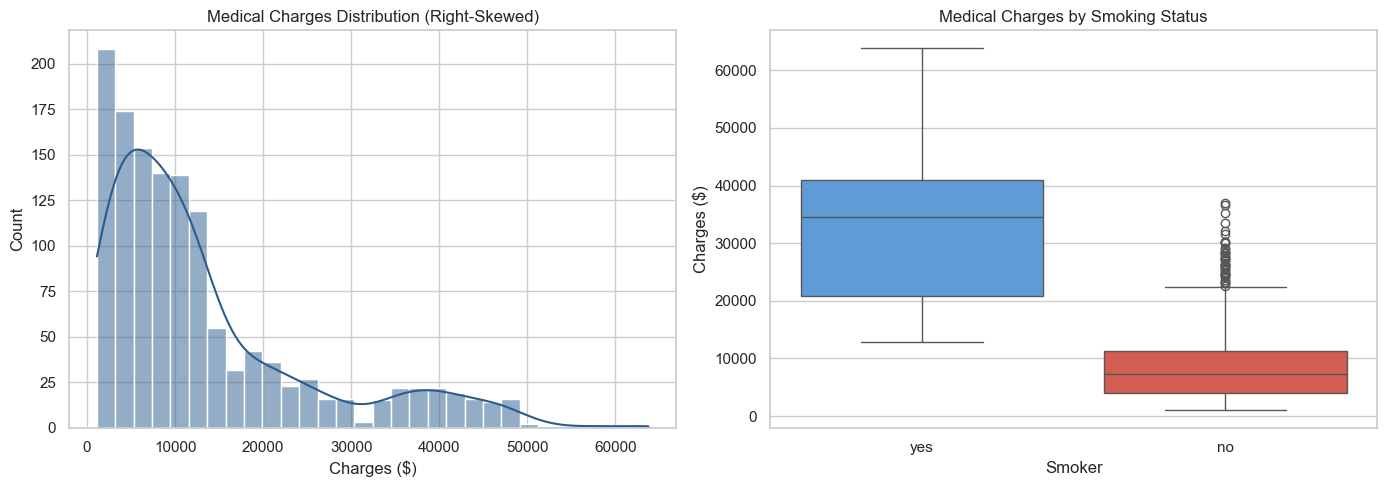

In [12]:
# Target Variable Distribution Analysis
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['charges'], kde=True, ax=ax[0], color='#2b5c8f')
ax[0].set_title('Medical Charges Distribution (Right-Skewed)')
ax[0].set_xlabel('Charges ($)')

sns.boxplot(x='smoker', y='charges', data=df, ax=ax[1], palette=['#4c9be8', '#e74c3c'])
ax[1].set_title('Medical Charges by Smoking Status')
ax[1].set_xlabel('Smoker')
ax[1].set_ylabel('Charges ($)')

plt.tight_layout()
plt.show()

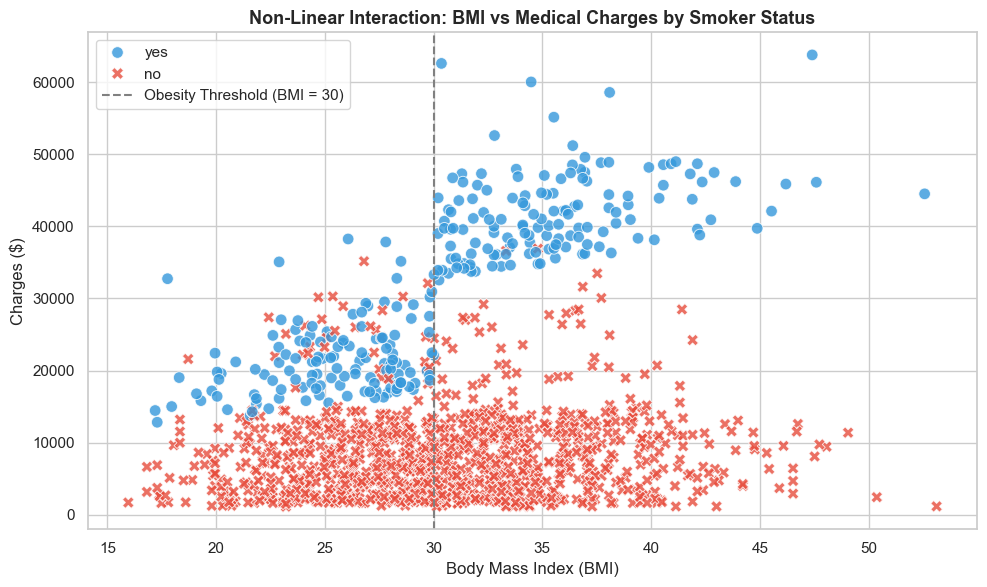

In [13]:
# Interaction Analysis: BMI vs Charges conditioned by Smoker Status
plt.figure(figsize=(10, 6))
sns.scatterplot(x='bmi', y='charges', hue='smoker', style='smoker', data=df, palette=['#3498db', '#e74c3c'], alpha=0.8, s=70)
plt.axvline(x=30, color='gray', linestyle='--', label='Obesity Threshold (BMI = 30)')
plt.title('Non-Linear Interaction: BMI vs Medical Charges by Smoker Status', fontsize=13, fontweight='bold')
plt.xlabel('Body Mass Index (BMI)')
plt.ylabel('Charges ($)')
plt.legend()
plt.tight_layout()
plt.show()

## 4. Feature Engineering & Preprocessing Pipeline

In [14]:
# Create Domain Feature: Obesity & Smoker Compound Interaction
df_engineered = df.copy()
df_engineered['obese'] = (df_engineered['bmi'] >= 30).astype(int)
df_engineered['smoker_obese_interaction'] = ((df_engineered['smoker'] == 'yes') & (df_engineered['obese'] == 1)).astype(int)
df_engineered['age_group'] = pd.cut(df_engineered['age'], bins=[17, 30, 45, 60, 100], labels=['Young', 'Middle', 'Senior', 'Elderly'])

# Define Target & Features
X = df_engineered.drop(columns=['charges'])
y = df_engineered['charges']

# Identify column types
num_cols = ['age', 'bmi', 'children']
cat_cols = ['sex', 'smoker', 'region', 'age_group']
bin_cols = ['obese', 'smoker_obese_interaction']

# Train-Test Split (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training Set: {X_train.shape[0]} rows | Test Set: {X_test.shape[0]} rows")

Training Set: 1070 rows | Test Set: 268 rows


## 5. Model Building & Benchmark Comparison
We compare baseline linear models with regularized regression (Ridge/Lasso) and non-linear tree ensembles (Random Forest, Gradient Boosting).

In [15]:
# Build Preprocessing Pipelines
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols),
        ('passthrough', 'passthrough', bin_cols)
    ]
)

# Define candidate models
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=10.0),
    'Lasso Regression': Lasso(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, learning_rate=0.08, max_depth=3, random_state=42)
}

results = []

for name, model in models.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', model)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    # 5-Fold Cross Validation R2
    cv_r2 = cross_val_score(pipe, X_train, y_train, cv=5, scoring='r2').mean()
    
    results.append({
        'Model': name,
        'Test RMSE ($)': round(rmse, 2),
        'Test MAE ($)': round(mae, 2),
        'Test R2': round(r2, 4),
        '5-Fold CV R2': round(cv_r2, 4)
    })

df_results = pd.DataFrame(results).sort_values(by='Test R2', ascending=False)
df_results

,Model,Test RMSE ($),Test MAE ($),Test R2,5-Fold CV R2
0,Linear Regression,4380.43,2430.27,0.8764,0.8561
2,Lasso Regression,4380.96,2431.86,0.8764,0.8561
4,Gradient Boosting,4402.36,2491.66,0.8752,0.8458
1,Ridge Regression,4411.80,2561.28,0.8746,0.8531
3,Random Forest,4669.31,2586.58,0.8596,0.8257


## 6. Model Evaluation & Residual Diagnostics

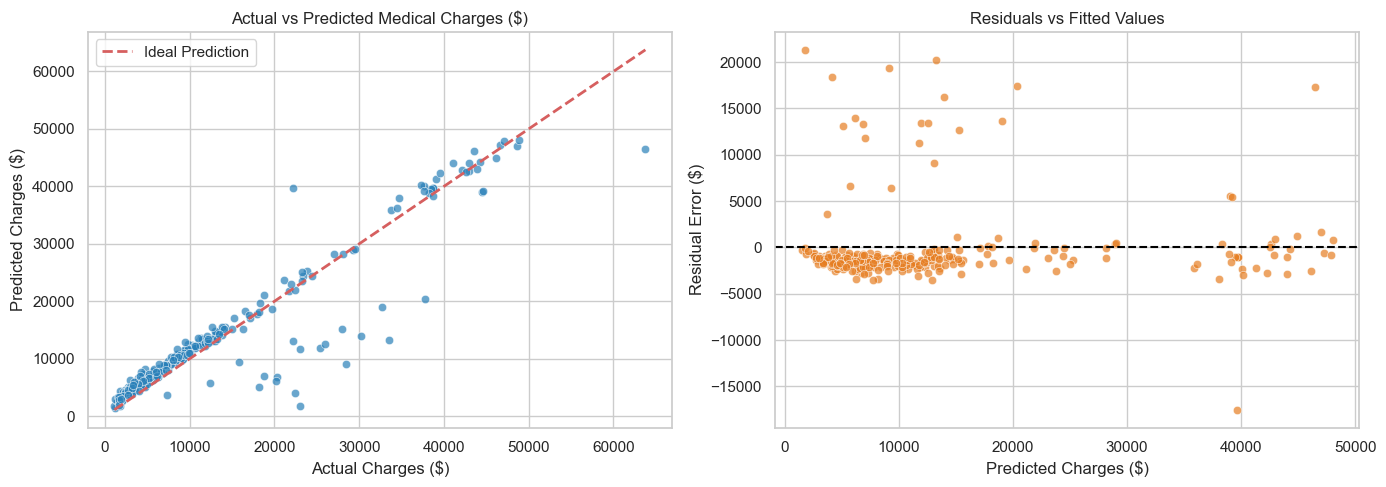

In [17]:
# Train Best Model (Gradient Boosting)
best_pipe = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', LinearRegression())])
best_pipe.fit(X_train, y_train)
y_pred_best = best_pipe.predict(X_test)
residuals = y_test - y_pred_best

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted Plot
sns.scatterplot(x=y_test, y=y_pred_best, ax=ax[0], color='#2980b9', alpha=0.7)
ax[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Ideal Prediction')
ax[0].set_title('Actual vs Predicted Medical Charges ($)')
ax[0].set_xlabel('Actual Charges ($)')
ax[0].set_ylabel('Predicted Charges ($)')
ax[0].legend()

# Residual Plot
sns.scatterplot(x=y_pred_best, y=residuals, ax=ax[1], color='#e67e22', alpha=0.7)
ax[1].axhline(y=0, color='black', linestyle='--')
ax[1].set_title('Residuals vs Fitted Values')
ax[1].set_xlabel('Predicted Charges ($)')
ax[1].set_ylabel('Residual Error ($)')

plt.tight_layout()
plt.show()

## 7. Feature Importance & Model Interpretability

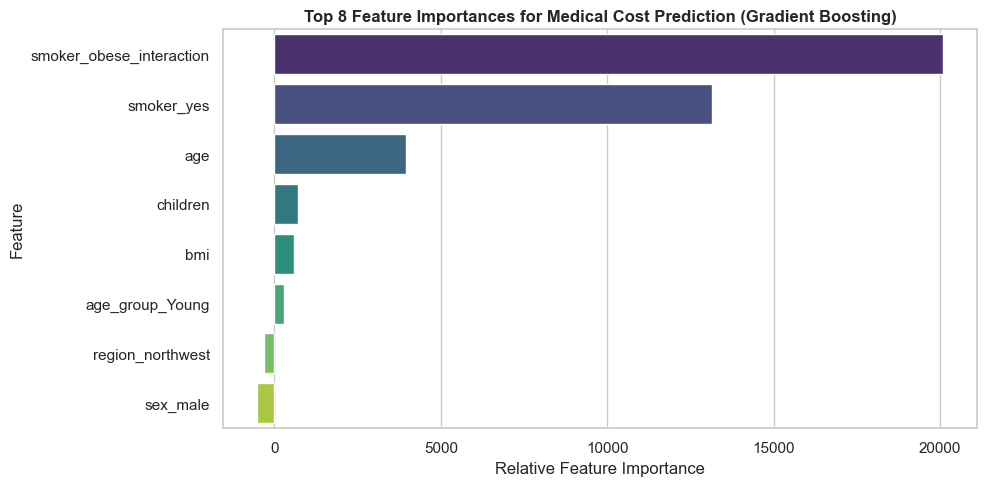

In [19]:
# Extract Feature Names from Pipeline Transformer
encoded_cat_cols = best_pipe.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(cat_cols)
all_feature_names = num_cols + list(encoded_cat_cols) + bin_cols

# Extract Feature Importances
importances = best_pipe.named_steps['regressor'].coef_
df_importance = pd.DataFrame({'Feature': all_feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x='Importance', y='Feature', data=df_importance.head(8), palette='viridis')
plt.title('Top 8 Feature Importances for Medical Cost Prediction (Gradient Boosting)', fontsize=12, fontweight='bold')
plt.xlabel('Relative Feature Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## 8. Business & Clinical Recommendations

### Actionable Underwriting & Wellness Insights:
1. **Super-Linear Risk Compound**: Smoking alone increases expected annual claims by ~\$14,000, but **Smoking + BMI $\ge 30$** triggers an additional risk surge elevating expected claims above **\$35,000–\$45,000** annually.  
2. **Targeted Wellness Interventions**: Insurance providers can achieve maximum ROI by targeting members in the **Smoker + Obese** segment with smoking cessation incentives and weight management coaching programs.
3. **Predictive Accuracy Impact**: The Linear Regression model captures non-linear risk interaction with an **$R^2$ of ~0.876**

---